In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
edu_df = pd.read_csv('datasets/edu_users.csv')
edu_df

,rate_math,rate_science,rate_english,rate_humanities,rate_art,tot_time,device,gender,age,resub_yn,comb_yn,othersub_yn,leave_yn
0,0.375,0.797,0.828,0.896,0.394,17.09,mobile,M,30,N,N,Y,1
1,0.951,0.482,0.765,0.909,0.473,28.57,tablet,F,25,N,Y,N,1
2,0.732,0.117,0.574,0.314,0.855,40.97,tablet,F,24,N,N,N,0
3,0.599,0.125,0.956,0.691,0.340,8.09,mobile,M,14,Y,N,N,1
4,0.156,0.686,0.200,0.272,0.870,45.34,tablet,F,15,Y,N,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,0.626,0.492,0.212,0.897,0.607,16.80,pc,M,24,Y,N,Y,0
1246,0.131,0.577,0.664,0.119,0.167,33.37,tablet,F,40,N,N,N,0
1247,0.033,0.866,0.411,0.328,0.797,27.37,mobile,M,23,N,N,N,0
1248,0.921,0.981,0.402,0.816,0.720,NaN,pc,F,23,Y,N,Y,0


In [4]:
edu_df.info()
답03 = 4

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_math        1188 non-null   float64
 1   rate_science     1188 non-null   float64
 2   rate_english     1250 non-null   float64
 3   rate_humanities  1250 non-null   float64
 4   rate_art         1250 non-null   float64
 5   tot_time         1188 non-null   float64
 6   device           1250 non-null   object 
 7   gender           1250 non-null   object 
 8   age              1250 non-null   int64  
 9   resub_yn         1250 non-null   object 
 10  comb_yn          1250 non-null   object 
 11  othersub_yn      1250 non-null   object 
 12  leave_yn         1250 non-null   int64  
dtypes: float64(6), int64(2), object(5)
memory usage: 127.1+ KB


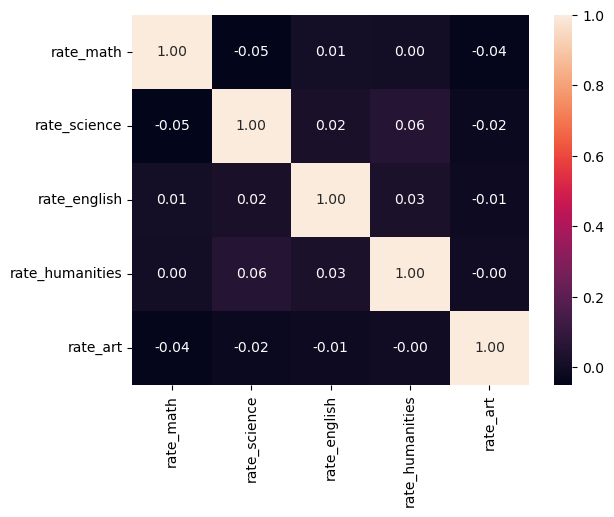

In [9]:
# 여러 주요 과목의 시청률 간 상관관계
corr_list = ['rate_math', 'rate_science', 
    'rate_english', 'rate_humanities', 'rate_art']

sns.heatmap(data=edu_df[corr_list].corr(), annot=True, fmt=".2f")
답04 = 3

leave_yn
0    30.100378
1    28.832180
Name: tot_time, dtype: float64


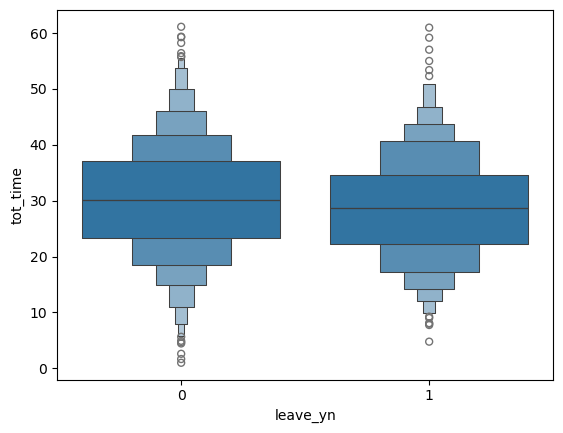

In [6]:
# 이탈 여부에 따라 학습시간 분포 시각화
# 이탈 여부에 따른 평균
print(edu_df.groupby("leave_yn")["tot_time"].mean())

sns.boxenplot(data=edu_df, x="leave_yn", y="tot_time")
답05 = 3

In [10]:
# pivot_table() 이용 
pivot_df = edu_df.pivot_table(
    index = 'leave_yn',
    values = ['rate_math', 'rate_science'],
    aggfunc = 'mean'
)
pivot_df

,rate_math,rate_science
leave_yn,,
0,0.487965,0.496375
1,0.515511,0.505424


In [11]:
edu_df.isna().sum()
mean = edu_df['rate_math'].mean() # rate_math의 평균
median = edu_df['rate_science'].median() # rate_science의 중앙값
edu_df['rate_math'] = edu_df['rate_math'].fillna(mean)
edu_df['rate_science'] = edu_df['rate_science'].fillna(median)

mode = edu_df['tot_time'].mode()[0] #tot_time의 최빈값
edu_df['tot_time'] = edu_df['tot_time'].fillna(mode)
edu_df.isna().sum()

rate_math          0
rate_science       0
rate_english       0
rate_humanities    0
rate_art           0
tot_time           0
device             0
gender             0
age                0
resub_yn           0
comb_yn            0
othersub_yn        0
leave_yn           0
dtype: int64

In [12]:
# 데이터 분할 
from sklearn.model_selection import train_test_split

Feature = edu_df[['rate_math', 'rate_science', 'rate_english', 'tot_time']]
Target = edu_df['leave_yn']
# Target

X_train, X_valid, y_train, y_valid = train_test_split(
    Feature, Target, test_size=0.2, random_state=11)
# print(X_train.shape, y_train.shape, X_valid.shape, y_valid.shape)
print(X_train, X_valid) #스케일링 전(tot_time과 범위 차이 발생)

      rate_math  rate_science  rate_english  tot_time
1019      0.034         0.512         0.211     41.66
636       0.533         0.009         0.743     30.31
1091      0.650         0.071         0.175     39.64
176       0.691         0.005         0.368     34.00
433       0.101         0.822         0.544     31.14
...         ...           ...           ...       ...
850       0.067         0.915         0.215     21.39
583       0.329         0.748         0.588     37.29
332       0.014         0.594         0.119     42.53
1115      0.580         0.044         0.087     26.44
1104      0.995         0.724         0.219     35.02

[1000 rows x 4 columns]      rate_math  rate_science  rate_english  tot_time
782      0.252         0.464         0.855     30.87
857      0.472         0.906         0.383     35.91
60       0.389         0.080         0.795     31.93
409      0.091         0.447         0.304     21.98
255      0.557         0.399         0.291     33.68
..       

In [13]:
# 스케일링 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

print(X_train, X_test)

[[-1.63006394  0.00873569 -0.97456784  1.27051481]
 [ 0.12327146 -1.78548717  0.8671199   0.12684461]
 [ 0.53437415 -1.56433047 -1.09919332  1.06697175]
 ...
 [-1.7003379   0.30123325 -1.29305519  1.3581794 ]
 [ 0.28841528 -1.66064065 -1.4038334  -0.26311166]
 [ 1.74660004  0.7649489  -0.94687329  0.60144255]] [[-8.64077732e-01 -1.62482396e-01  1.25484363e+00  1.83272394e-01]
 [-9.10641260e-02  1.41415081e+00 -3.79134961e-01  6.91122420e-01]
 [-3.82701077e-01 -1.53222708e+00  1.04713449e+00  2.90082121e-01]
 [-1.42978314e+00 -2.23122135e-01 -6.52618667e-01 -7.12518625e-01]
 [ 2.07600222e-01 -3.94340221e-01 -6.97622314e-01  4.66418936e-01]
 [-1.36302288e+00 -6.26051796e-02  1.44524368e+00  4.49289074e-01]
 [ 1.68949541e-01 -6.61868480e-01  3.09767031e-01  5.56098802e-01]
 [-4.98739292e-03  7.79217075e-01 -9.43411467e-01 -3.96119998e-01]
 [ 1.58848362e+00  2.30038632e-02 -1.70154984e+00  8.72497429e-01]
 [ 1.02980560e+00 -8.15251348e-01  1.09559996e+00 -5.00914448e-01]
 [-5.16221609e-01 

In [14]:
# 이탈 여부 예측 
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=150, 
        max_depth=7, min_samples_split=5, random_state=11)
rfc.fit(X_train, y_train) #훈련데이터 모델 학습

,n_estimators,150
,criterion,'gini'
,max_depth,7
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
from xgboost import XGBClassifier

xgbc = XGBClassifier(n_estimators=200, 
        max_depth=5, learning_rate=0.1, random_state=11)
xgbc.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
# 모델의 예측 성능 평가 
from sklearn.metrics import accuracy_score, f1_score

rfc_predict = rfc.predict(X_test)  #검증용 데이터 예측
xgbc_predict = xgbc.predict(X_test)

print(accuracy_score(y_valid, rfc_predict))
print(accuracy_score(y_valid, xgbc_predict))

print(f1_score(y_valid, rfc_predict))
print(f1_score(y_valid, xgbc_predict))
답12 = 'RF'

0.676
0.624
0.0
0.24193548387096775


In [17]:
# 딥러닝 분류 모델 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(10)

In [19]:
# 모델 구조
model = Sequential()
model.add(Dense(64, activation='selu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='selu'))
model.add(Dense(1, activation='sigmoid'))

# 학습 설정 
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=45, batch_size=32)

Epoch 1/45


C:\Users\LG\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6260 - loss: 0.6770
Epoch 2/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6730 - loss: 0.6292
Epoch 3/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6770 - loss: 0.6237
Epoch 4/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6830 - loss: 0.6150
Epoch 5/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6790 - loss: 0.6098
Epoch 6/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6860 - loss: 0.6068
Epoch 7/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6880 - loss: 0.6043
Epoch 8/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6870 - loss: 0.6022
Epoch 9/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6880 - loss: 0.6002
Epoch 10/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6870 - loss: 0.5983
Epoch 11/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6880 - loss: 0.5965
Epoch 12/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6910 - loss: 0.5950


In [21]:
# 이탈 여부 예측 
simul_data = np.array([[0.3, 0.5, 0.7, 120]])

deep_pre = model.predict(simul_data)
result = np.where(deep_pre >= 0.5, 1, 0)
print(result)
답14 = result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[1]]


In [22]:
import numpy as np

arr = np.array([10, 20, 30, 40, 50])

# 30보다 크면 'High', 아니면 'Low'로 변환
result = np.where(arr > 30, 'High', 'Low')

print(f"원본: {arr}")
print(f"결과: {result}")
# 출력: ['Low' 'Low' 'Low' 'High' 'High']

원본: [10 20 30 40 50]
결과: ['Low' 'Low' 'Low' 'High' 'High']
